# 04 · Subsetting and sketching

[Chapter 03](03_normalisation.ipynb) handed you one clean object holding every cell that
survived quality control. This chapter is about deliberately taking **less** of it.

Two different reasons to do that, and they need different tools:

- **Your question is narrower than the dataset.** You care about four organelle markers
  and three compounds. Cut the rows and columns you do not need — *subsetting*.
- **The dataset is larger than the method.** A neighbour graph over 653,000 cells is slow
  enough that you stop experimenting, which hurts the analysis more than any
  approximation. Take fewer cells, but not at random — *sketching*.

By the end you will have built both, because the rest of the book needs one of each:

| | | |
|---|---|---|
| `mcs2026_controls.h5ad` | every DMSO and PBS cell | **[Stage 2](../2_controls/intro.md)** learns the whole toolkit on it |
| `mcs2026_sketch.h5ad` | ~30,000 cells spanning all 18 conditions | [Part 4](../../part4_final_solutions/intro.md) embeds the plate with it |

The contrast between them is the point of the chapter. One is small enough to use whole;
the other is not, and has to be sampled with care.

| | |
|---|---|
| **1** | Subset by marker |
| **2** | Subset by condition — and build the controls |
| **3** | Subset by cell — and why random is not good enough |
| **4** | Sketch the geometry instead |
| **5** | Check what you kept, and save |

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc

sys.path.insert(0, str(Path.cwd().parents[2] / "src"))

from mcs2026 import analysis, panels, plotting
from mcs2026.config import H5AD_SLIM

plotting.set_style()
pd.set_option("display.width", 140)

cells = sc.read_h5ad(H5AD_SLIM.with_name("mcs2026_clean.h5ad"))
print(f"{cells.n_obs:,} cells x {cells.n_vars} markers "
      f"({cells.n_obs * cells.n_vars * 4 / 1e9:.2f} GB as float32)")

65,349 cells x 38 markers (0.01 GB as float32)


## 1 · Subset by marker

This is what [Step 7](01_columns_to_markers.ipynb) bought you. Before the rename, `var`
held 4,464 strings and there was no way to ask for "the ER markers". Now there is.

In [2]:
cells.var.groupby("theme", observed=True).agg(
    markers=("marker", "nunique"),
    rounds=("round", lambda r: f"{r.min()}–{r.max()}"),
).sort_values("markers", ascending=False)

,markers,rounds
theme,,
signaling,10,0–24
mechanics,8,2–27
identity,7,1–14
metabolism,5,15–28
organelles,5,3–25
cell_cycle,3,3–14


**A whole theme**, using the panel definitions in `mcs2026.panels`:

Note that this returns more markers than the table above lists for `organelles`. The
`theme` column holds each marker's *primary* theme — one label per marker, so the counts
add up to 38 — while a **panel** is the set of markers you would want to look at for a
question, and those overlap on purpose. Calreticulin is an ER protein and a metabolic
readout; the lamins are organelle and mechanics both.

In [3]:
organelle_markers = panels.resolve_panel(cells.var, "organelles")
print(f"  organelles: {len(organelle_markers)} markers")
cells.var.loc[organelle_markers, ["marker", "round", "channel"]]

  organelles: 11 markers


,marker,round,channel
EEA1,EEA1,3,FITC
GM130,GM130,4,Texas Red
Giantin,Giantin,20,FITC
LAMP1,LAMP1,21,Cy5
DDX6,DDX6,25,Cy5
Calreticulin,Calreticulin,28,FITC
GRP78,GRP78,18,Texas Red
Pmp70,Pmp70,17,Cy5
Mitochondria,Mitochondria,15,FITC
LaminA,LaminA,27,Cy5


**A hand-picked set**, when your question does not match a theme:

In [4]:
my_markers = ["LAMP1", "EEA1", "GM130", "Giantin"]
chosen = cells.var.index[cells.var.marker.isin(my_markers)].tolist()
print(f"  {len(chosen)} columns: {chosen}")

  4 columns: ['EEA1', 'GM130', 'Giantin', 'LAMP1']


:::{note}
**When you need more than 38 columns.** The clean object carries one number per antibody
per cell — *how much* of a protein there is. If your question is about *how it is
arranged* — whether the Golgi is compact or dispersed, whether lysosomes are punctate —
the texture features are the measurement, and they are back in the wide table.

Reading its `var` costs nothing, because `backed="r"` opens the file without loading it
([Step 5](01_columns_to_markers.ipynb)):
:::

In [5]:
wide_var = sc.read_h5ad(H5AD_SLIM.with_name("mcs2026_qc.h5ad"), backed="r").var
mine = wide_var[wide_var.marker.isin(my_markers)]
print(f"  in the clean object : {len(chosen):5d} columns")
print(f"  in the wide table   : {len(mine):5d} columns")
print(mine.family.value_counts().to_string())

  in the clean object :     4 columns
  in the wide table   :   252 columns
family
Texture       232
Intensity      20
Morphology      0
Population      0


## 2 · Subset by condition — and build the controls

The plate holds two conditions that are not treatments. **DMSO** is the vehicle the
compounds were dissolved in; **PBS** is buffer. Both were meant to leave the cells alone.

That makes them the right place to learn every method in Stage 2. A technique run on
treated cells will show you *something*, and you will not know whether the something is
the biology or the method. Run it on two conditions where nothing should be happening and
any structure you find is structure you made.

In [6]:
CONTROLS = ["DMSO", "PBS"]
controls = cells[cells.obs.condition.astype(str).isin(CONTROLS)].copy()

print(f"  {cells.n_obs:,} cells -> {controls.n_obs:,} ({controls.n_obs / cells.n_obs:.0%})")
pd.crosstab(controls.obs.condition.astype(str), controls.obs.timepoint_h.astype(int))

  65,349 cells -> 9,698 (15%)


timepoint_h,36,48,60,84
condition,,,,
DMSO,701,971,1786,2823
PBS,374,564,925,1554


Thirty-two wells and four timepoints. Small enough that **Stage 2 uses every cell of it** —
no sampling, no sketch, nothing to caveat. Section 4 is about what to do when you are not
that lucky.

### Any other subset works the same way

In [7]:
my_conditions = ["DMSO", "Sapanisertib/INK128", "MK-2206", "Wortmannin"]
subset = cells[cells.obs.condition.astype(str).isin(my_conditions)]
print(f"  {cells.n_obs:,} -> {subset.n_obs:,} cells, {subset.obs.well.nunique()} wells")

late = cells[cells.obs.timepoint_h.astype(int).isin([60, 84])]
print(f"  60 and 84 h only: {late.n_obs:,} cells, "
      f"{late.obs.condition.nunique()} conditions still present")

  65,349 -> 15,282 cells, 56 wells
  60 and 84 h only: 47,403 cells, 18 conditions still present


:::{important}
**Keep DMSO.** Every value in `X` is expressed as a distance from the control cells of the
same timepoint, and every comparison you will make is against them. A subset without
controls cannot be re-normalised, cannot be compared, and cannot be plotted on a
meaningful axis.

The same goes for timepoints: keep at least two, or you cannot say anything changed.
:::

## 3 · Subset by cell — and why random is not good enough

The wrong way first, because it looks reasonable:

In [8]:
naive = cells[:20_000]
print("  cells[:20_000] gives you:")
print(f"    {naive.obs.well.nunique()} of {cells.obs.well.nunique()} wells")
print(f"    {naive.obs.condition.nunique()} of {cells.obs.condition.nunique()} conditions")
print(f"    timepoints: {sorted(naive.obs.timepoint_h.astype(int).unique().tolist())}")

  cells[:20_000] gives you:
    74 of 223 wells
    16 of 18 conditions
    timepoints: [36, 48, 60, 84]


The file is written well by well, so `cells[:20_000]` is not a sample of the experiment
— it is whichever wells happen to sit at the top of the file. Read the counts printed
above: wells are missing, and so are whole conditions. Any analysis of that describes
those wells.

Two honest alternatives. **Uniform random** keeps the plate's proportions;
**stratified** takes the same number from every condition × timepoint:

In [9]:
rng = np.random.default_rng(0)
uniform = np.sort(rng.choice(cells.n_obs, 8_000, replace=False))
balanced = analysis.stratified(cells.obs, 8_000)

for name, index in [("uniform", uniform), ("stratified", balanced)]:
    obs = cells.obs.iloc[index]
    print(f"  {name:11s} {len(index):,} cells, {obs.well.nunique()} wells, "
          f"{obs.condition.nunique()} conditions, "
          f"smallest condition {obs.condition.value_counts().min()}")

  uniform     8,000 cells, 223 wells, 18 conditions, smallest condition 271
  stratified  7,992 cells, 223 wells, 18 conditions, smallest condition 444


:::{warning}
A stratified subsample is **balanced, not representative**. Every condition gets the
same number of cells, so the proportions in it no longer match the plate.

Use it to *look* — embeddings, distributions, a quick heatmap. Compute proportions and
statistics on the full table, at the well level.
:::

## 4 · Sketch the geometry instead

The controls did not need any of this — 32 wells fit in memory and in patience. The whole
plate is a different matter, and [Part 4](../../part4_final_solutions/intro.md) has to
embed all eighteen conditions at once. This section is for that case.

Both samplers above are balanced across the **plate**: conditions, timepoints, wells.
Neither knows anything about the **measurements**. And a cell state that exists in every
well but in only 1% of cells is rare in exactly the way that matters — it is rare in the
data space, not on the plate.

Uniform sampling keeps 1% of a 1% population. Stratifying by condition does not help,
because the rarity is not a condition.

**Geometric sketching** (Hie et al., 2019) samples the space rather than the rows. It
lays a grid over the data and takes roughly one cell per occupied box, so a region
holding 40 cells and a region holding 40,000 contribute about equally.

In [10]:
matrix = np.asarray(cells.X)
# 30,000 cells is a comfortable size for a neighbour graph. The cap keeps the sketch a
# genuine reduction when this notebook is run on a smaller extract of the plate.
TARGET = min(30_000, cells.n_obs // 8)

sketch_index = analysis.sketch(matrix, TARGET)
print(f"  {cells.n_obs:,} cells -> {len(sketch_index):,} ({len(sketch_index)/cells.n_obs:.0%})")

  65,349 cells -> 8,168 (12%)


:::{admonition} Why is there no PCA in front of this?
:class: dropdown

Because the published recipe *does* put one there, and it is worth knowing why we can
skip it.

The grid is what makes sketching work, and two things break a grid in high dimensions:
every cell ends up alone in its own box, and the distances that define the boxes get
dominated by whichever columns are noisiest. PCA is the standard fix — it denoises,
decorrelates, and cuts to something like 100 dimensions.

Our input has already had all three done to it. Thirty-eight columns, each an antibody
averaged over the whole cell and then scaled against its own controls in
[Step 17](03_normalisation.ipynb). The reduction happened in Stage 1.

You *would* need a PCA to sketch the wide table: 2,262 of its 2,587 columns are texture,
so they outvote the 38 markers sixty to one and the geometry becomes a picture of
texture rather than of protein. That is Exercise 2.
:::

### Does it actually keep more?

Define "unusual" without using any labels: the 1% of cells furthest from the centre of
the marker space. Then count how many of them each sample retains.

In [11]:
distance = np.linalg.norm(matrix - matrix.mean(axis=0), axis=1)
unusual = distance >= np.quantile(distance, 0.99)

comparison = pd.DataFrame([
    {"sample": name,
     "cells": len(index),
     "unusual kept": int(unusual[index].sum()),
     "% of the sample": round(100 * unusual[index].mean(), 1)}
    for name, index in [("uniform", uniform), ("stratified", balanced),
                        ("geosketch", analysis.sketch(matrix, 8_000))]
]).set_index("sample")
comparison["of all unusual cells"] = (
    100 * comparison["unusual kept"] / unusual.sum()).round(1)
comparison

,cells,unusual kept,% of the sample,of all unusual cells
sample,,,,
uniform,8000,81,1.0,12.4
stratified,7992,94,1.2,14.4
geosketch,8000,283,3.5,43.3


All three samples are the same size, so this is a like-for-like comparison. Uniform and
stratified sampling reproduce the population — roughly 1% of the sample is unusual,
because roughly 1% of the plate is. The sketch deliberately over-represents them.

A second view of the same thing: split the marker space into 100 regions, and count how
many cells each sample draws from the ten emptiest ones.

  100 regions: smallest holds 45 cells, largest 2,158


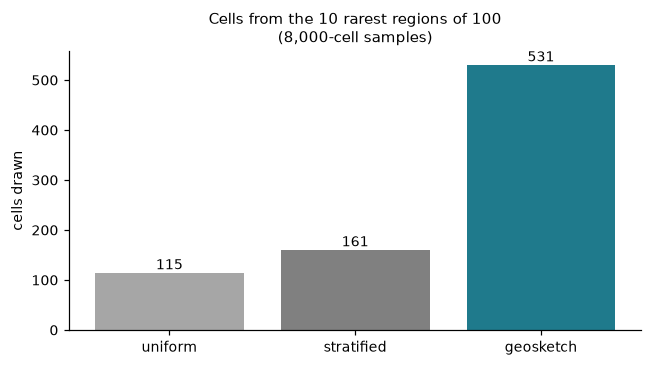

In [12]:
from sklearn.cluster import MiniBatchKMeans

regions = MiniBatchKMeans(n_clusters=100, random_state=0, n_init=3).fit_predict(matrix)
sizes = np.bincount(regions, minlength=100)
rarest = set(np.argsort(sizes)[:10].tolist())
print(f"  100 regions: smallest holds {sizes.min():,} cells, largest {sizes.max():,}")

fig, ax = plt.subplots(figsize=(6, 3.4))
labels = ["uniform", "stratified", "geosketch"]
counts = [int(np.isin(regions[i], list(rarest)).sum())
          for i in [uniform, balanced, analysis.sketch(matrix, 8_000)]]
ax.bar(labels, counts, color=["0.65", "0.5", "#1f7a8c"])
for x, value in enumerate(counts):
    ax.text(x, value, f"{value}", ha="center", va="bottom")
ax.set(ylabel="cells drawn", title="Cells from the 10 rarest regions of 100\n(8,000-cell samples)")
fig.tight_layout()

:::{warning}
**A sketch is for looking, not for counting.** It over-represents rare cells on purpose,
so any proportion computed on it is wrong — and wrong in a direction that flatters
whatever is rare.

Everything downstream respects this split: embeddings and clustering run on the sketch,
every proportion and every statistic runs on the full table at the well level.
:::

### Keep the map back

A sketch is only useful if you can put its answer back on the whole dataset. Record
which cells were taken, in both directions.

In [13]:
in_sketch = np.zeros(cells.n_obs, dtype=bool)
in_sketch[sketch_index] = True
cells.obs["in_sketch"] = in_sketch

sketch = cells[sketch_index].copy()
sketch.uns["sketch_of"] = "mcs2026_clean.h5ad"
sketch.uns["sketch_method"] = "geosketch.gs on the 38 normalised markers"
sketch.uns["sketch_size"] = int(len(sketch_index))
sketch.uns["source_n_obs"] = int(cells.n_obs)

print(f"  sketch: {sketch.n_obs:,} cells x {sketch.n_vars} markers")
print(f"  every condition present: {sketch.obs.condition.nunique() == cells.obs.condition.nunique()}")
print(f"  every well present     : {sketch.obs.well.nunique()} of {cells.obs.well.nunique()}")

  sketch: 8,168 cells x 38 markers
  every condition present: True
  every well present     : 223 of 223


## 5 · Check what you kept, and save

One cell, every time. It catches the subset that silently lost a group.

In [14]:
def describe_subset(adata, *, control="DMSO"):
    obs = adata.obs
    return pd.Series({
        "cells": f"{adata.n_obs:,}",
        "markers": adata.n_vars,
        "wells": obs.well.nunique(),
        "conditions": obs.condition.nunique(),
        "timepoints": obs.timepoint_h.nunique(),
        "control present": control in set(obs.condition.astype(str)),
        "min cells per condition": int(obs.condition.value_counts().min()),
        "GB as float32": round(adata.n_obs * adata.n_vars * 4 / 1e9, 4),
    }, name="subset")

my_subset = cells[cells.obs.condition.astype(str).isin(my_conditions), organelle_markers]
pd.concat([describe_subset(cells).rename("clean"),
           describe_subset(controls).rename("controls"),
           describe_subset(sketch).rename("sketch"),
           describe_subset(my_subset).rename("organelles ×4 conditions")], axis=1)

,clean,controls,sketch,organelles ×4 conditions
cells,"65,349","9,698","8,168","15,282"
markers,38,38,38,11
wells,223,32,223,56
conditions,18,2,18,4
timepoints,4,4,4,4
control present,True,True,True,True
min cells per condition,2316,3417,237,2316
GB as float32,0.0099,0.0015,0.0012,0.0007


Read the `conditions` row across the columns. The **controls** keep 2 of 18 by design and
the **sketch** keeps all 18 by design — they are cut along different axes for different
reasons, and mixing them up is how you end up embedding a sample that cannot answer your
question.

### Views cost nothing; copies cost memory

Slicing an `AnnData` gives you a **view**. Nothing is allocated until you copy it or write
it out.

In [15]:
view = cells[cells.obs.condition.astype(str).isin(my_conditions), organelle_markers]
print(f"  view : {type(view).__name__:12s} is_view={view.is_view}")
copy = view.copy()
print(f"  copy : {type(copy).__name__:12s} is_view={copy.is_view}   "
      f"{copy.n_obs * copy.n_vars * 4 / 1e6:.0f} MB")
print(f"  the clean table itself is {cells.n_obs * cells.n_vars * 4 / 1e9:.2f} GB")

  view : AnnData      is_view=True
  copy : AnnData      is_view=False   1 MB
  the clean table itself is 0.01 GB


That is the memory lesson from [Step 11](02_quality_control.ipynb) paying off. Slice
freely; copy deliberately.

### Write down what each file is

`my_subset.h5ad` on a shared cluster three weeks from now is otherwise a mystery,
including to you. `uns` is where that goes.

In [16]:
controls.uns["subset_of"] = "mcs2026_clean.h5ad"
controls.uns["subset_conditions"] = CONTROLS
controls.uns["subset_reason"] = "the two untreated conditions; Stage 2 works on all of them"

copy.uns["subset_of"] = "mcs2026_clean.h5ad"
copy.uns["subset_conditions"] = my_conditions
copy.uns["subset_theme"] = "organelles"

controls.write_h5ad(H5AD_SLIM.with_name("mcs2026_controls.h5ad"), compression="gzip")
sketch.write_h5ad(H5AD_SLIM.with_name("mcs2026_sketch.h5ad"), compression="gzip")
cells.write_h5ad(H5AD_SLIM.with_name("mcs2026_clean.h5ad"), compression="gzip")
copy.write_h5ad(H5AD_SLIM.with_name("my_subset.h5ad"), compression="gzip")

print(f"  mcs2026_controls.h5ad {controls.n_obs:>7,} cells   <- Stage 2 opens this")
print(f"  mcs2026_sketch.h5ad   {sketch.n_obs:>7,} cells   <- Part 4 opens this")
print(f"  mcs2026_clean.h5ad    {cells.n_obs:>7,} cells   <- now carries obs['in_sketch']")
print(f"  my_subset.h5ad        {copy.n_obs:>7,} cells   <- yours")

  mcs2026_controls.h5ad   9,698 cells   <- Stage 2 opens this
  mcs2026_sketch.h5ad     8,168 cells   <- Part 4 opens this
  mcs2026_clean.h5ad     65,349 cells   <- now carries obs['in_sketch']
  my_subset.h5ad         15,282 cells   <- yours


## Stage 1 is complete

| file | one row per | what it is for |
|---|---|---|
| `mcs2026_clean.h5ad` | cell | the full, normalised, annotated dataset |
| `mcs2026_controls.h5ad` | cell | DMSO and PBS, all of them — **Stage 2** |
| `mcs2026_sketch.h5ad` | cell | ~30,000 covering all 18 conditions — Part 4 |
| `mcs2026_wells.parquet` | well | every statistical test |
| `mcs2026_slim.h5ad` | cell | the wide 2,587-column archive, for texture questions |

[Stage 2](../2_controls/intro.md) opens the controls and learns every method on them.

---

## Exercises

### 1. Build your group's subset

Pick one of the four themes. Build a subset with that theme's markers, all conditions and
all timepoints, and save it. How large is it, and does it pass `describe_subset`?

:::{admonition} Solution
:class: dropdown

```python
theme = "signaling"          # or mechanics / metabolism / organelles
mine = cells[:, panels.resolve_panel(cells.var, theme)].copy()
mine.uns["subset_theme"] = theme
print(describe_subset(mine))
mine.write_h5ad(H5AD_SLIM.with_name(f"{theme}.h5ad"), compression="gzip")
```

Keeping every condition matters more than keeping every cell: you cannot add a condition
back later, but you can always subsample further.
:::

### 2. Sketch the wide table, with and without a PCA

Take `mcs2026_qc.h5ad`, sketch it straight, then sketch it again after
`PCA(n_components=50)`. How much do the two sketches overlap? Which markers are the
cells they disagree about extreme in?

:::{admonition} Solution
:class: dropdown

```python
wide = sc.read_h5ad(H5AD_SLIM.with_name("mcs2026_qc.h5ad"))
raw = np.log2(np.asarray(wide.X) + 1)
straight = analysis.sketch(raw, 8_000)
reduced = analysis.sketch(PCA(n_components=50, random_state=0).fit_transform(raw), 8_000)
print(f"overlap: {len(set(straight) & set(reduced)):,} of 8,000")
```

The overlap is small. Sketched straight, the geometry is dominated by the 2,262 texture
columns, so the cells picked are the ones with unusual *texture* — often the largest or
most out-of-focus objects. After a PCA the columns are decorrelated first, so no block of
near-duplicate features can outvote the rest.

Neither sketch is wrong. They answer different questions, which is exactly why the choice
of space matters more than the choice of sampler.
:::

### 3. Break a subset on purpose

Build one without DMSO. Then try to express a marker as a shift from the control. What
exactly fails, and at which line?

:::{admonition} Solution
:class: dropdown

`analysis.effect_table` drops the control row and has nothing to centre on, so you get
either an empty frame or all-NaN — depending on the path, possibly with no error at all.

That is the point of the exercise. A missing control does not raise; it produces numbers
that look fine and mean nothing. The one-cell check in section 5 exists to catch it, and
`control present` is the row to read first.
:::

---

**Next:** [Stage 2 — The toolkit, on the controls](../2_controls/intro.md).